# Collinearity Reduction and Academic Feature Engineering

The semester-level academic variables contain several related measures,
including numbers of curricular units enrolled, evaluated, approved,
credited, and completed without evaluation.

This notebook investigates whether replacing these correlated raw counts
with more compact and interpretable engineered features can reduce
collinearity while preserving logistic-regression predictive performance.

Three representations are compared:

1. Original raw academic predictors
2. Semester-level engineered rates
3. Compact cross-semester summary features

In [1]:
# ============================================================
# 1. Imports and Data Loading
# ============================================================

import sys
from pathlib import Path

cwd = Path.cwd()
project_root = cwd if (cwd / "requirements.txt").exists() else cwd.parent
sys.path.append(str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from src.preprocessing import (
    load_data,
    TARGET_COL,
    NUMERIC_COLS,
    CATEGORICAL_COLS,
    BINARY_COLS
)

from src.models import get_logistic_regression

sns.set_theme(style="whitegrid")

df = load_data()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [2]:
# ============================================================
# 2. Identify Semester-Level Academic Variables
# ============================================================

sem1_cols = [
    col for col in NUMERIC_COLS
    if "Curricular units 1st sem" in col
]

sem2_cols = [
    col for col in NUMERIC_COLS
    if "Curricular units 2nd sem" in col
]

academic_raw_cols = sem1_cols + sem2_cols

print("Semester 1 variables:")
for col in sem1_cols:
    print(" -", col)

print("\nSemester 2 variables:")
for col in sem2_cols:
    print(" -", col)

print("\nTotal raw academic variables:", len(academic_raw_cols))

Semester 1 variables:
 - Curricular units 1st sem (credited)
 - Curricular units 1st sem (enrolled)
 - Curricular units 1st sem (evaluations)
 - Curricular units 1st sem (approved)
 - Curricular units 1st sem (grade)
 - Curricular units 1st sem (without evaluations)

Semester 2 variables:
 - Curricular units 2nd sem (credited)
 - Curricular units 2nd sem (enrolled)
 - Curricular units 2nd sem (evaluations)
 - Curricular units 2nd sem (approved)
 - Curricular units 2nd sem (grade)
 - Curricular units 2nd sem (without evaluations)

Total raw academic variables: 12


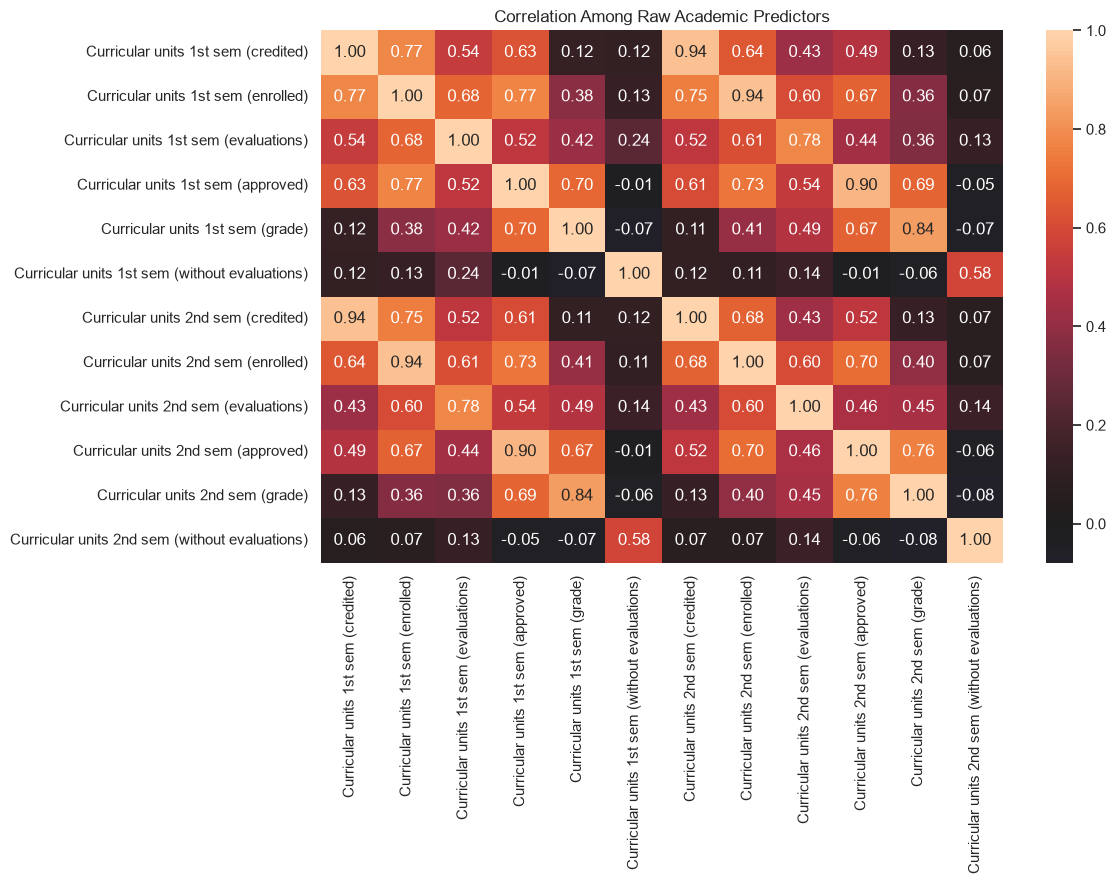

In [3]:
# ============================================================
# 3. Correlation Among Original Academic Predictors
# ============================================================

academic_corr = df[academic_raw_cols].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    academic_corr,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Correlation Among Raw Academic Predictors")

plt.tight_layout()
plt.show()

In [4]:
def get_high_corr_pairs(data, columns, threshold=0.80):
    """
    Return predictor pairs whose absolute Pearson correlation
    exceeds the specified threshold.
    """

    corr = data[columns].corr()

    upper_triangle = corr.where(
        np.triu(
            np.ones(corr.shape),
            k=1
        ).astype(bool)
    )

    pairs = (
        upper_triangle
        .stack()
        .reset_index()
    )

    pairs.columns = [
        "Feature 1",
        "Feature 2",
        "Correlation"
    ]

    pairs["Absolute Correlation"] = (
        pairs["Correlation"].abs()
    )

    return (
        pairs[
            pairs["Absolute Correlation"] >= threshold
        ]
        .sort_values(
            "Absolute Correlation",
            ascending=False
        )
        .reset_index(drop=True)
    )

original_high_corr = get_high_corr_pairs(
    df,
    academic_raw_cols,
    threshold=0.80
)

display(original_high_corr)

print(
    "Number of academic predictor pairs with |r| >= 0.80:",
    len(original_high_corr)
)

,Feature 1,Feature 2,Correlation,Absolute Correlation
0,Curricular units 1st sem (credited),Curricular units 2nd sem (credited),0.944811,0.944811
1,Curricular units 1st sem (enrolled),Curricular units 2nd sem (enrolled),0.942627,0.942627
2,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),0.904002,0.904002
3,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),0.837170,0.837170


Number of academic predictor pairs with |r| >= 0.80: 4


In [5]:
# ============================================================
# 4. Common Train/Test Split
# ============================================================

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    stratify=df[TARGET_COL],
    random_state=42
)

y_train = df.loc[train_idx, TARGET_COL]
y_test = df.loc[test_idx, TARGET_COL]

print("Training observations:", len(train_idx))
print("Testing observations:", len(test_idx))

print("\nTraining class proportions:")
display(y_train.value_counts(normalize=True).round(3))

print("Testing class proportions:")
display(y_test.value_counts(normalize=True).round(3))

Training observations: 3539
Testing observations: 885

Training class proportions:


Target
Graduate    0.499
Dropout     0.321
Enrolled    0.179
Name: proportion, dtype: float64

Testing class proportions:


Target
Graduate    0.499
Dropout     0.321
Enrolled    0.180
Name: proportion, dtype: float64

In [6]:
# ============================================================
# 5. Helper Functions
# ============================================================

def safe_ratio(numerator, denominator):
    """
    Compute a ratio while treating zero denominators as missing.

    Missing values will later be imputed inside the modeling pipeline.
    """

    denominator_safe = denominator.replace(0, np.nan)

    return numerator / denominator_safe

def build_experiment_pipeline(
    numeric_cols,
    categorical_cols=CATEGORICAL_COLS,
    binary_cols=BINARY_COLS
):
    """
    Build a balanced multinomial logistic-regression pipeline.

    Numeric predictors:
      - median imputation
      - standardization

    Categorical predictors:
      - one-hot encoding

    Binary predictors:
      - passed through unchanged
    """

    numeric_transformer = Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_transformer,
                numeric_cols
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_cols
            ),
            (
                "bin",
                "passthrough",
                binary_cols
            )
        ]
    )

    return Pipeline([
        (
            "preprocess",
            preprocessor
        ),
        (
            "model",
            get_logistic_regression(
                random_state=42
            )
        )
    ])

def evaluate_predictions(
    y_true,
    y_pred,
    representation_name
):
    """
    Return overall and class-specific classification metrics.
    """

    return {
        "Representation": representation_name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Macro F1": f1_score(
            y_true,
            y_pred,
            average="macro"
        ),

        "Dropout Recall": recall_score(
            y_true,
            y_pred,
            labels=["Dropout"],
            average=None
        )[0],

        "Enrolled Recall": recall_score(
            y_true,
            y_pred,
            labels=["Enrolled"],
            average=None
        )[0],

        "Graduate Recall": recall_score(
            y_true,
            y_pred,
            labels=["Graduate"],
            average=None
        )[0]
    }

In [7]:
# ============================================================
# 6. Representation A: Original Raw Academic Predictors
# ============================================================

baseline_numeric_cols = NUMERIC_COLS.copy()

baseline_feature_cols = (
    baseline_numeric_cols
    + CATEGORICAL_COLS
    + BINARY_COLS
)

X_baseline = df[baseline_feature_cols]

X_train_baseline = X_baseline.loc[train_idx]
X_test_baseline = X_baseline.loc[test_idx]

In [8]:
baseline_pipe = build_experiment_pipeline(
    numeric_cols=baseline_numeric_cols
)

baseline_pipe.fit(
    X_train_baseline,
    y_train
)

baseline_pred = baseline_pipe.predict(
    X_test_baseline
)

baseline_results = evaluate_predictions(
    y_test,
    baseline_pred,
    "Original Raw Academic Features"
)

baseline_results

{'Representation': 'Original Raw Academic Features',
 'Accuracy': 0.7231638418079096,
 'Macro F1': 0.6852254543066828,
 'Dropout Recall': np.float64(0.6901408450704225),
 'Enrolled Recall': np.float64(0.6163522012578616),
 'Graduate Recall': np.float64(0.7828054298642534)}

In [9]:
# ============================================================
# 7. Representation B: Semester-Level Engineered Rates
# ============================================================

df_rates = df.copy()

# Semester 1
df_rates["Sem1 approval rate"] = safe_ratio(
    df_rates["Curricular units 1st sem (approved)"],
    df_rates["Curricular units 1st sem (enrolled)"]
)

df_rates["Sem1 evaluation rate"] = safe_ratio(
    df_rates["Curricular units 1st sem (evaluations)"],
    df_rates["Curricular units 1st sem (enrolled)"]
)

df_rates["Sem1 credit rate"] = safe_ratio(
    df_rates["Curricular units 1st sem (credited)"],
    df_rates["Curricular units 1st sem (enrolled)"]
)

df_rates["Sem1 no-evaluation rate"] = safe_ratio(
    df_rates["Curricular units 1st sem (without evaluations)"],
    df_rates["Curricular units 1st sem (enrolled)"]
)

# Semester 2
df_rates["Sem2 approval rate"] = safe_ratio(
    df_rates["Curricular units 2nd sem (approved)"],
    df_rates["Curricular units 2nd sem (enrolled)"]
)

df_rates["Sem2 evaluation rate"] = safe_ratio(
    df_rates["Curricular units 2nd sem (evaluations)"],
    df_rates["Curricular units 2nd sem (enrolled)"]
)

df_rates["Sem2 credit rate"] = safe_ratio(
    df_rates["Curricular units 2nd sem (credited)"],
    df_rates["Curricular units 2nd sem (enrolled)"]
)

df_rates["Sem2 no-evaluation rate"] = safe_ratio(
    df_rates["Curricular units 2nd sem (without evaluations)"],
    df_rates["Curricular units 2nd sem (enrolled)"]
)

In [11]:
rate_academic_cols = [
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (grade)",
    "Sem1 approval rate",
    "Sem1 evaluation rate",
    "Sem1 credit rate",
    "Sem1 no-evaluation rate",

    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (grade)",
    "Sem2 approval rate",
    "Sem2 evaluation rate",
    "Sem2 credit rate",
    "Sem2 no-evaluation rate"
]

non_academic_numeric_cols = [
    col for col in NUMERIC_COLS
    if col not in academic_raw_cols
]

rate_numeric_cols = (
    non_academic_numeric_cols
    + rate_academic_cols
)

rate_feature_cols = (
    rate_numeric_cols
    + CATEGORICAL_COLS
    + BINARY_COLS
)

X_rates = df_rates[rate_feature_cols]

X_train_rates = X_rates.loc[train_idx]
X_test_rates = X_rates.loc[test_idx]

In [12]:
rate_pipe = build_experiment_pipeline(
    numeric_cols=rate_numeric_cols
)

rate_pipe.fit(
    X_train_rates,
    y_train
)

rate_pred = rate_pipe.predict(
    X_test_rates
)

rate_results = evaluate_predictions(
    y_test,
    rate_pred,
    "Semester-Level Engineered Rates"
)

rate_results

{'Representation': 'Semester-Level Engineered Rates',
 'Accuracy': 0.7265536723163842,
 'Macro F1': 0.6863663033559514,
 'Dropout Recall': np.float64(0.6936619718309859),
 'Enrolled Recall': np.float64(0.6037735849056604),
 'Graduate Recall': np.float64(0.7918552036199095)}

In [13]:
# ============================================================
# Missingness Created by Ratio Features
# ============================================================

rate_missing = (
    df_rates[rate_academic_cols]
    .isna()
    .sum()
    .reset_index()
)

rate_missing.columns = [
    "Feature",
    "Missing Values"
]

rate_missing["Missing Percent"] = (
    100
    * rate_missing["Missing Values"]
    / len(df_rates)
)

display(
    rate_missing[
        rate_missing["Missing Values"] > 0
    ].round(2)
)

,Feature,Missing Values,Missing Percent
2,Sem1 approval rate,180,4.07
3,Sem1 evaluation rate,180,4.07
4,Sem1 credit rate,180,4.07
5,Sem1 no-evaluation rate,180,4.07
8,Sem2 approval rate,180,4.07
9,Sem2 evaluation rate,180,4.07
10,Sem2 credit rate,180,4.07
11,Sem2 no-evaluation rate,180,4.07


In [14]:
# ============================================================
# 8. Representation C: Compact Academic Summary Features
# ============================================================

df_compact = df.copy()

df_compact["Total enrolled"] = (
    df_compact["Curricular units 1st sem (enrolled)"]
    + df_compact["Curricular units 2nd sem (enrolled)"]
)

df_compact["Overall approval rate"] = safe_ratio(
    (
        df_compact["Curricular units 1st sem (approved)"]
        + df_compact["Curricular units 2nd sem (approved)"]
    ),
    df_compact["Total enrolled"]
)

df_compact["Overall evaluation rate"] = safe_ratio(
    (
        df_compact["Curricular units 1st sem (evaluations)"]
        + df_compact["Curricular units 2nd sem (evaluations)"]
    ),
    df_compact["Total enrolled"]
)

df_compact["Overall credit rate"] = safe_ratio(
    (
        df_compact["Curricular units 1st sem (credited)"]
        + df_compact["Curricular units 2nd sem (credited)"]
    ),
    df_compact["Total enrolled"]
)

df_compact["Overall no-evaluation rate"] = safe_ratio(
    (
        df_compact["Curricular units 1st sem (without evaluations)"]
        + df_compact["Curricular units 2nd sem (without evaluations)"]
    ),
    df_compact["Total enrolled"]
)

# For weighted only
sem1_enrolled = df_compact[
    "Curricular units 1st sem (enrolled)"
]

sem2_enrolled = df_compact[
    "Curricular units 2nd sem (enrolled)"
]

sem1_grade = df_compact[
    "Curricular units 1st sem (grade)"
]

sem2_grade = df_compact[
    "Curricular units 2nd sem (grade)"
]

df_compact["Weighted average grade"] = safe_ratio(
    (
        sem1_grade * sem1_enrolled
        + sem2_grade * sem2_enrolled
    ),
    (
        sem1_enrolled
        + sem2_enrolled
    )
)

df_compact["Grade change"] = (
    df_compact["Curricular units 2nd sem (grade)"]
    - df_compact["Curricular units 1st sem (grade)"]
)

In [15]:
compact_academic_cols = [
    "Total enrolled",
    "Overall approval rate",
    "Overall evaluation rate",
    "Overall credit rate",
    "Overall no-evaluation rate",
    "Weighted average grade",
    "Grade change"
]

compact_numeric_cols = (
    non_academic_numeric_cols
    + compact_academic_cols
)

compact_feature_cols = (
    compact_numeric_cols
    + CATEGORICAL_COLS
    + BINARY_COLS
)

X_compact = df_compact[
    compact_feature_cols
]

X_train_compact = X_compact.loc[
    train_idx
]

X_test_compact = X_compact.loc[
    test_idx
]

compact_pipe = build_experiment_pipeline(
    numeric_cols=compact_numeric_cols
)

compact_pipe.fit(
    X_train_compact,
    y_train
)

compact_pred = compact_pipe.predict(
    X_test_compact
)

compact_results = evaluate_predictions(
    y_test,
    compact_pred,
    "Compact Academic Summaries"
)

compact_results

{'Representation': 'Compact Academic Summaries',
 'Accuracy': 0.7299435028248588,
 'Macro F1': 0.6908446163765313,
 'Dropout Recall': np.float64(0.704225352112676),
 'Enrolled Recall': np.float64(0.610062893081761),
 'Graduate Recall': np.float64(0.7895927601809954)}

In [16]:
compact_missing = (
    df_compact[compact_academic_cols]
    .isna()
    .sum()
    .reset_index()
)

compact_missing.columns = [
    "Feature",
    "Missing Values"
]

compact_missing["Missing Percent"] = (
    100
    * compact_missing["Missing Values"]
    / len(df_compact)
)

display(
    compact_missing[
        compact_missing["Missing Values"] > 0
    ].round(2)
)

,Feature,Missing Values,Missing Percent
1,Overall approval rate,180,4.07
2,Overall evaluation rate,180,4.07
3,Overall credit rate,180,4.07
4,Overall no-evaluation rate,180,4.07
5,Weighted average grade,180,4.07


# 9. Compare collinearity before and after

In [17]:
display(original_high_corr)

,Feature 1,Feature 2,Correlation,Absolute Correlation
0,Curricular units 1st sem (credited),Curricular units 2nd sem (credited),0.944811,0.944811
1,Curricular units 1st sem (enrolled),Curricular units 2nd sem (enrolled),0.942627,0.942627
2,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),0.904002,0.904002
3,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),0.837170,0.837170


In [18]:
rate_high_corr = get_high_corr_pairs(
    df_rates,
    rate_academic_cols,
    threshold=0.80
)

display(rate_high_corr)

print(
    "Highly correlated pairs in rate representation:",
    len(rate_high_corr)
)

,Feature 1,Feature 2,Correlation,Absolute Correlation
0,Curricular units 1st sem (enrolled),Curricular units 2nd sem (enrolled),0.942627,0.942627
1,Sem1 credit rate,Sem2 credit rate,0.914608,0.914608
2,Curricular units 2nd sem (grade),Sem2 approval rate,0.859260,0.859260
3,Sem1 approval rate,Sem2 approval rate,0.853019,0.853019
4,Curricular units 1st sem (grade),Sem1 approval rate,0.839517,0.839517
5,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),0.837170,0.837170
6,Sem1 approval rate,Curricular units 2nd sem (grade),0.804732,0.804732


Highly correlated pairs in rate representation: 7


In [19]:
compact_high_corr = get_high_corr_pairs(
    df_compact,
    compact_academic_cols,
    threshold=0.80
)

display(compact_high_corr)

print(
    "Highly correlated pairs in compact representation:",
    len(compact_high_corr)
)

,Feature 1,Feature 2,Correlation,Absolute Correlation
0,Overall approval rate,Weighted average grade,0.886933,0.886933


Highly correlated pairs in compact representation: 1


In [20]:
collinearity_summary = pd.DataFrame({
    "Representation": [
        "Original Raw Academic Features",
        "Semester-Level Engineered Rates",
        "Compact Academic Summaries"
    ],

    "Academic Features": [
        len(academic_raw_cols),
        len(rate_academic_cols),
        len(compact_academic_cols)
    ],

    "Pairs with |r| >= 0.80": [
        len(original_high_corr),
        len(rate_high_corr),
        len(compact_high_corr)
    ]
})

display(collinearity_summary)

,Representation,Academic Features,Pairs with |r| >= 0.80
0,Original Raw Academic Features,12,4
1,Semester-Level Engineered Rates,12,7
2,Compact Academic Summaries,7,1


# 10. Compact correlation heatmap

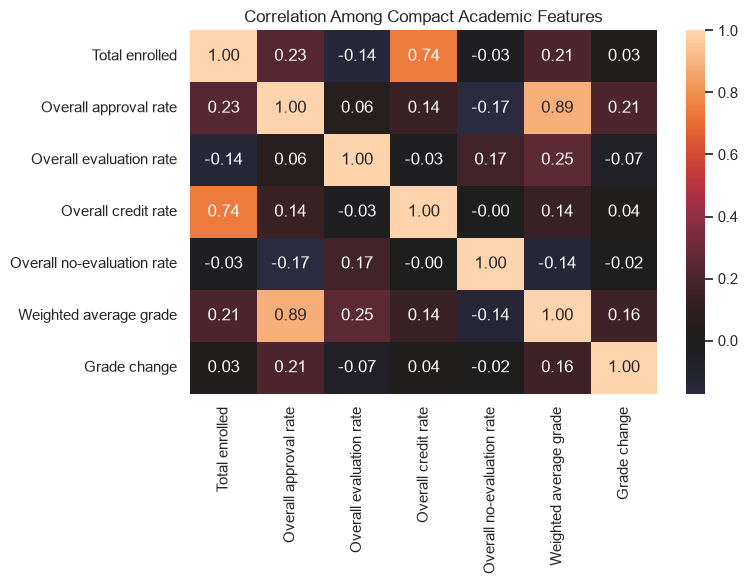

In [21]:
compact_corr = df_compact[
    compact_academic_cols
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    compact_corr,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title(
    "Correlation Among Compact Academic Features"
)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 11. Holdout Performance Comparison
# ============================================================

holdout_results = pd.DataFrame([
    baseline_results,
    rate_results,
    compact_results
])

display(
    holdout_results.round(4)
)

baseline_f1 = holdout_results.loc[
    holdout_results["Representation"]
    == "Original Raw Academic Features",
    "Macro F1"
].iloc[0]

holdout_results["Delta Macro F1"] = (
    holdout_results["Macro F1"]
    - baseline_f1
)

display(
    holdout_results.round(4)
)

,Representation,Accuracy,Macro F1,Dropout Recall,Enrolled Recall,Graduate Recall
0,Original Raw Academic Features,0.7232,0.6852,0.6901,0.6164,0.7828
1,Semester-Level Engineered Rates,0.7266,0.6864,0.6937,0.6038,0.7919
2,Compact Academic Summaries,0.7299,0.6908,0.7042,0.6101,0.7896


,Representation,Accuracy,Macro F1,Dropout Recall,Enrolled Recall,Graduate Recall,Delta Macro F1
0,Original Raw Academic Features,0.7232,0.6852,0.6901,0.6164,0.7828,0.0000
1,Semester-Level Engineered Rates,0.7266,0.6864,0.6937,0.6038,0.7919,0.0011
2,Compact Academic Summaries,0.7299,0.6908,0.7042,0.6101,0.7896,0.0056


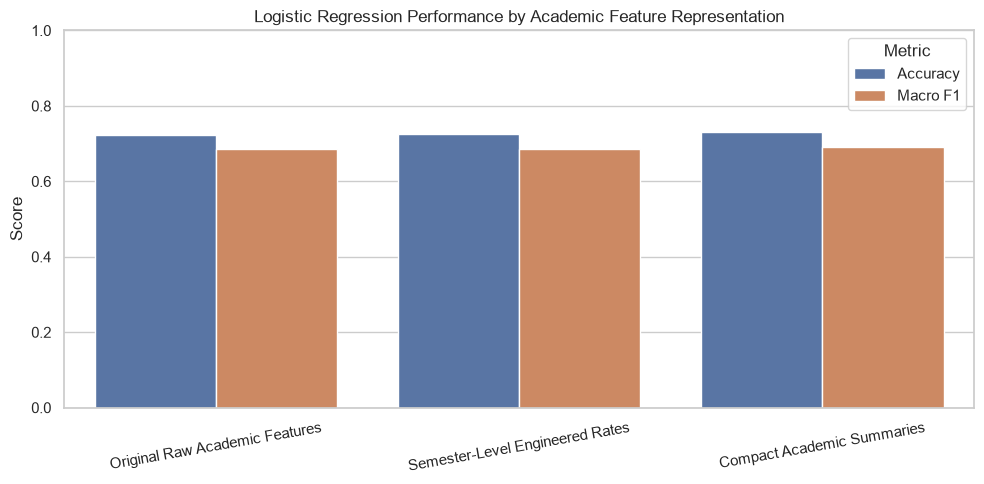

In [23]:
performance_long = (
    holdout_results
    .melt(
        id_vars="Representation",
        value_vars=[
            "Accuracy",
            "Macro F1"
        ],
        var_name="Metric",
        value_name="Score"
    )
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=performance_long,
    x="Representation",
    y="Score",
    hue="Metric",
    ax=ax
)

ax.set_ylim(0, 1)

ax.set_title(
    "Logistic Regression Performance by Academic Feature Representation"
)

ax.set_xlabel("")
ax.set_ylabel("Score")

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

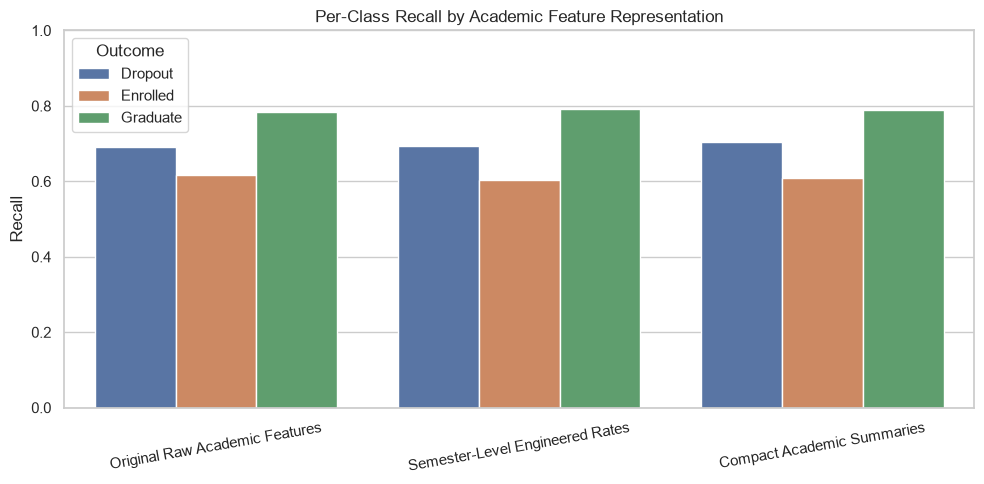

In [24]:
recall_long = (
    holdout_results
    .melt(
        id_vars="Representation",
        value_vars=[
            "Dropout Recall",
            "Enrolled Recall",
            "Graduate Recall"
        ],
        var_name="Outcome",
        value_name="Recall"
    )
)

recall_long["Outcome"] = (
    recall_long["Outcome"]
    .str.replace(
        " Recall",
        "",
        regex=False
    )
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=recall_long,
    x="Representation",
    y="Recall",
    hue="Outcome",
    ax=ax
)

ax.set_ylim(0, 1)

ax.set_title(
    "Per-Class Recall by Academic Feature Representation"
)

ax.set_xlabel("")
ax.set_ylabel("Recall")

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

# Feature count comparison

In [25]:
def transformed_feature_count(pipe):
    """
    Number of predictors after preprocessing.
    """

    return len(
        pipe.named_steps[
            "preprocess"
        ].get_feature_names_out()
    )

feature_count_results = pd.DataFrame({
    "Representation": [
        "Original Raw Academic Features",
        "Semester-Level Engineered Rates",
        "Compact Academic Summaries"
    ],

    "Academic Features Before Preprocessing": [
        len(academic_raw_cols),
        len(rate_academic_cols),
        len(compact_academic_cols)
    ],

    "Total Features After Preprocessing": [
        transformed_feature_count(baseline_pipe),
        transformed_feature_count(rate_pipe),
        transformed_feature_count(compact_pipe)
    ]
})

display(feature_count_results)

,Representation,Academic Features Before Preprocessing,Total Features After Preprocessing
0,Original Raw Academic Features,12,234
1,Semester-Level Engineered Rates,12,242
2,Compact Academic Summaries,7,234


The compact representation reduces the academic representation from 12 variables to 7, although the total transformed feature count remains nearly unchanged because missing-value indicators are introduced for undefined ratios.

In [26]:
final_holdout_summary = (
    holdout_results
    .merge(
        feature_count_results,
        on="Representation"
    )
    .merge(
        collinearity_summary,
        on="Representation"
    )
)

display(
    final_holdout_summary.round(4)
)

,Representation,Accuracy,Macro F1,Dropout Recall,Enrolled Recall,Graduate Recall,Delta Macro F1,Academic Features Before Preprocessing,Total Features After Preprocessing,Academic Features,Pairs with |r| >= 0.80
0,Original Raw Academic Features,0.7232,0.6852,0.6901,0.6164,0.7828,0.0000,12,234,12,4
1,Semester-Level Engineered Rates,0.7266,0.6864,0.6937,0.6038,0.7919,0.0011,12,242,12,7
2,Compact Academic Summaries,0.7299,0.6908,0.7042,0.6101,0.7896,0.0056,7,234,7,1


# CV

In [27]:
# ============================================================
# 15. 5-Fold Cross-Validation on Training Data
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "macro_recall": "recall_macro"
}

baseline_cv_pipe = build_experiment_pipeline(
    numeric_cols=baseline_numeric_cols
)

baseline_cv = cross_validate(
    baseline_cv_pipe,
    X_train_baseline,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

rate_cv_pipe = build_experiment_pipeline(
    numeric_cols=rate_numeric_cols
)

rate_cv = cross_validate(
    rate_cv_pipe,
    X_train_rates,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

compact_cv_pipe = build_experiment_pipeline(
    numeric_cols=compact_numeric_cols
)

compact_cv = cross_validate(
    compact_cv_pipe,
    X_train_compact,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [28]:
cv_results = pd.DataFrame({
    "Representation": [
        "Original Raw Academic Features",
        "Semester-Level Engineered Rates",
        "Compact Academic Summaries"
    ],

    "Mean Accuracy": [
        baseline_cv["test_accuracy"].mean(),
        rate_cv["test_accuracy"].mean(),
        compact_cv["test_accuracy"].mean()
    ],

    "SD Accuracy": [
        baseline_cv["test_accuracy"].std(),
        rate_cv["test_accuracy"].std(),
        compact_cv["test_accuracy"].std()
    ],

    "Mean Macro F1": [
        baseline_cv["test_macro_f1"].mean(),
        rate_cv["test_macro_f1"].mean(),
        compact_cv["test_macro_f1"].mean()
    ],

    "SD Macro F1": [
        baseline_cv["test_macro_f1"].std(),
        rate_cv["test_macro_f1"].std(),
        compact_cv["test_macro_f1"].std()
    ],

    "Mean Macro Recall": [
        baseline_cv["test_macro_recall"].mean(),
        rate_cv["test_macro_recall"].mean(),
        compact_cv["test_macro_recall"].mean()
    ],

    "SD Macro Recall": [
        baseline_cv["test_macro_recall"].std(),
        rate_cv["test_macro_recall"].std(),
        compact_cv["test_macro_recall"].std()
    ]
})

display(
    cv_results.round(4)
)

,Representation,Mean Accuracy,SD Accuracy,Mean Macro F1,SD Macro F1,Mean Macro Recall,SD Macro Recall
0,Original Raw Academic Features,0.7570,0.0151,0.7157,0.0169,0.7229,0.0179
1,Semester-Level Engineered Rates,0.7590,0.0172,0.7178,0.0165,0.7249,0.0160
2,Compact Academic Summaries,0.7604,0.0133,0.7200,0.0136,0.7272,0.0134


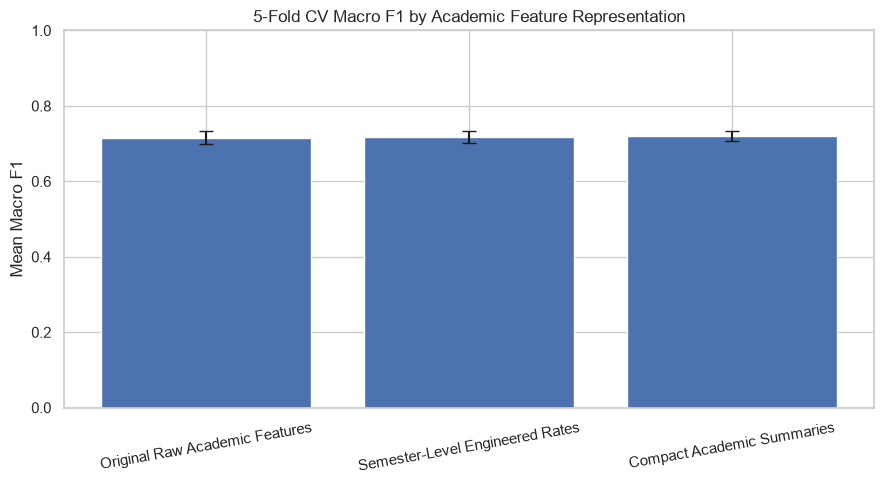

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    cv_results["Representation"],
    cv_results["Mean Macro F1"],
    yerr=cv_results["SD Macro F1"],
    capsize=5
)

ax.set_ylim(0, 1)

ax.set_title(
    "5-Fold CV Macro F1 by Academic Feature Representation"
)

ax.set_ylabel("Mean Macro F1")
ax.set_xlabel("")

plt.xticks(rotation=10)

plt.tight_layout()
plt.show()

# Efficiency plot

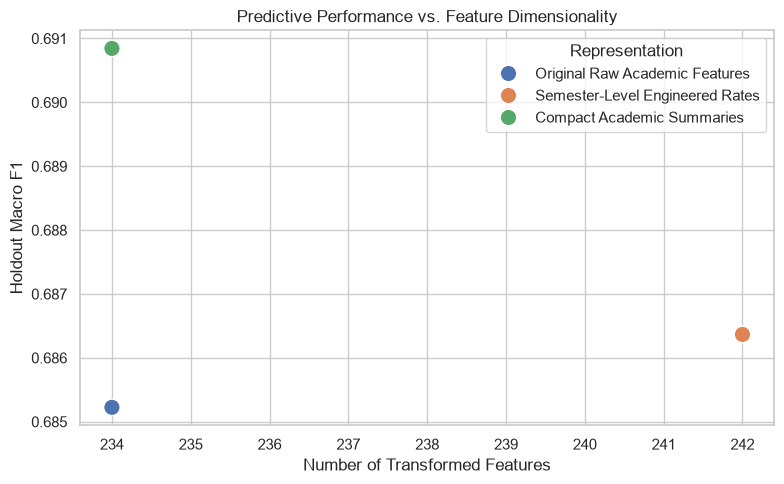

In [32]:
efficiency_results = (
    holdout_results
    .merge(
        feature_count_results,
        on="Representation"
    )
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=efficiency_results,
    x="Total Features After Preprocessing",
    y="Macro F1",
    hue="Representation",
    s=140,
    ax=ax
)

ax.set_title(
    "Predictive Performance vs. Feature Dimensionality"
)

ax.set_xlabel(
    "Number of Transformed Features"
)

ax.set_ylabel(
    "Holdout Macro F1"
)

plt.tight_layout()
plt.show()

In [34]:
final_summary = (
    final_holdout_summary
    .merge(
        cv_results[
            [
                "Representation",
                "Mean Macro F1",
                "SD Macro F1"
            ]
        ],
        on="Representation"
    )
)

display(
    final_summary[
        [
            "Representation",
            "Academic Features",
            "Pairs with |r| >= 0.80",
            "Total Features After Preprocessing",
            "Accuracy",
            "Macro F1",
            "Delta Macro F1",
            "Mean Macro F1",
            "SD Macro F1"
        ]
    ].round(4)
)

,Representation,Academic Features,Pairs with |r| >= 0.80,Total Features After Preprocessing,Accuracy,Macro F1,Delta Macro F1,Mean Macro F1,SD Macro F1
0,Original Raw Academic Features,12,4,234,0.7232,0.6852,0.0000,0.7157,0.0169
1,Semester-Level Engineered Rates,12,7,242,0.7266,0.6864,0.0011,0.7178,0.0165
2,Compact Academic Summaries,7,1,234,0.7299,0.6908,0.0056,0.7200,0.0136


# VIF

In [35]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(data, columns):
    """
    Calculate VIF for a numeric feature set.

    Missing values are median-imputed for this diagnostic,
    and an intercept is included in the auxiliary regressions.
    """

    X_vif = data[columns].copy()

    # Median-impute missing values for the VIF diagnostic
    X_vif = X_vif.fillna(
        X_vif.median()
    )

    # Remove zero-variance columns
    X_vif = X_vif.loc[
        :,
        X_vif.nunique() > 1
    ]

    # Include an intercept for conventional VIF calculation
    X_with_const = add_constant(
        X_vif,
        has_constant="add"
    )

    vif_df = pd.DataFrame({
        "Feature": X_vif.columns,
        "VIF": [
            variance_inflation_factor(
                X_with_const.values,
                i
            )
            for i in range(
                1,
                X_with_const.shape[1]
            )
        ]
    })

    return vif_df.sort_values(
        "VIF",
        ascending=False
    )

original_vif = calculate_vif(
    df,
    academic_raw_cols
)

rate_vif = calculate_vif(
    df_rates,
    rate_academic_cols
)

compact_vif = calculate_vif(
    df_compact,
    compact_academic_cols
)

print("Original:")
display(original_vif.round(2))

print("Rates:")
display(rate_vif.round(2))

print("Compact:")
display(compact_vif.round(2))

Original:


,Feature,VIF
1,Curricular units 1st sem (enrolled),23.01
7,Curricular units 2nd sem (enrolled),16.17
0,Curricular units 1st sem (credited),15.45
3,Curricular units 1st sem (approved),12.48
6,Curricular units 2nd sem (credited),12.32
9,Curricular units 2nd sem (approved),10.07
10,Curricular units 2nd sem (grade),5.44
4,Curricular units 1st sem (grade),4.94
2,Curricular units 1st sem (evaluations),3.85
8,Curricular units 2nd sem (evaluations),3.31


Rates:


,Feature,VIF
0,Curricular units 1st sem (enrolled),12.89
6,Curricular units 2nd sem (enrolled),10.86
10,Sem2 credit rate,7.12
4,Sem1 credit rate,6.67
8,Sem2 approval rate,5.82
2,Sem1 approval rate,5.69
7,Curricular units 2nd sem (grade),5.68
1,Curricular units 1st sem (grade),5.05
9,Sem2 evaluation rate,2.15
3,Sem1 evaluation rate,2.09


Compact:


,Feature,VIF
5,Weighted average grade,5.88
1,Overall approval rate,5.54
0,Total enrolled,1.80
3,Overall credit rate,1.76
2,Overall evaluation rate,1.32
4,Overall no-evaluation rate,1.08
6,Grade change,1.05


The original semester-level academic variables exhibit substantial redundancy, particularly between analogous first- and second-semester measures. Four pairs of raw academic predictors had absolute correlations of at least 0.80, and several variables also had large VIF values, including values above 10.

Replacing raw counts with semester-specific rates did not substantially reduce this dependence. The rate representation contained seven predictor pairs with absolute correlations of at least 0.80, and several VIF values remained elevated. This indicates that normalizing academic counts by enrollment does not necessarily resolve multicollinearity.

The compact cross-semester representation was more effective. It reduced the academic feature set from 12 variables to 7, reduced the number of highly correlated predictor pairs from four to one, and substantially lowered the largest VIF values. The largest VIF in the compact representation was approximately 5.88, compared with values above 20 in the original representation.

Despite this simplification, predictive performance was preserved and slightly improved. Holdout macro F1 increased from 0.6852 for the original representation to 0.6908 for the compact representation. Five-fold cross-validation also slightly favored the compact representation, with mean macro F1 increasing from 0.7157 to 0.7200.

The compact representation increased dropout recall from 0.6901 to 0.7042 while enrolled-student recall decreased slightly from 0.6164 to 0.6101. Graduate recall increased from 0.7828 to 0.7896. These differences are relatively small, so the main advantage of the compact representation is reduced redundancy and improved interpretability rather than a large gain in predictive performance.

Overall, the compact academic representation appears preferable when interpretability and reduced collinearity are priorities. The semester-specific rate representation provides little advantage over the original raw variables.